In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import norm

In [2]:
data = pd.read_csv(
    "../data/SPY_processed_data.csv",
    index_col=0,
    parse_dates=True
)

data.head()

,Close,High,Low,Open,Volume,Returns,Rolling_Volatility
Price,,,,,,,
2010-01-05,84.802368,84.839686,84.220253,84.526240,111579900.0,0.002644,NaN
2010-01-06,84.862061,85.071024,84.653097,84.720261,116074400.0,0.000704,NaN
2010-01-07,85.220322,85.324804,84.466554,84.705371,131091100.0,0.004213,NaN
2010-01-08,85.503891,85.541208,84.824759,84.996405,126402800.0,0.003322,NaN
2010-01-11,85.623299,85.921815,85.257606,85.884503,106375700.0,0.001396,NaN


In [13]:
test = data[
    data.index >= "2023-01-01"
]

In [3]:
confidence_level = 0.95

historical_var = (
    data["Returns"]
    .quantile(
        1-confidence_level
    )
)

historical_var

np.float64(-0.016665236115176736)

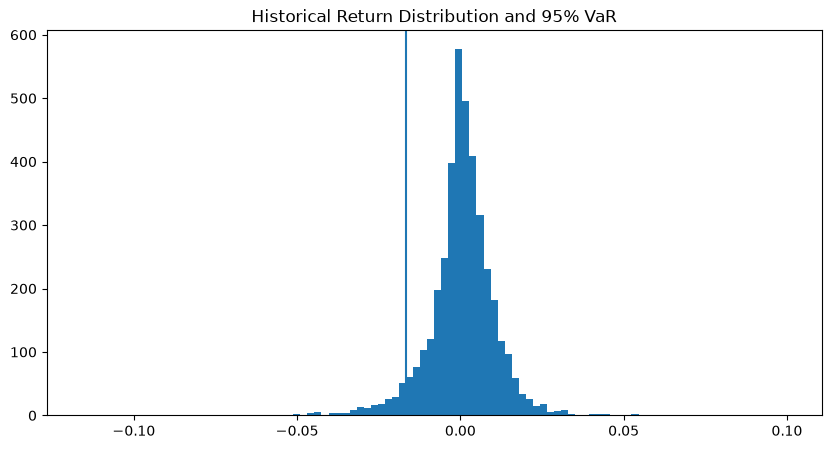

In [4]:
plt.figure(figsize=(10,5))

plt.hist(
    data["Returns"],
    bins=100
)

plt.axvline(
    historical_var
)

plt.title(
    "Historical Return Distribution and 95% VaR"
)

plt.show()

In [5]:
#### Parametric VaR
mean_return = (
    data["Returns"]
    .mean()
)


volatility = (
    data["Returns"]
    .std()
)


z_score = norm.ppf(
    0.05
)


parametric_var = (
    mean_return
    +
    z_score * volatility
)


parametric_var

np.float64(-0.017350896238610573)

In [7]:
garch_rolling = pd.read_csv(
    "../data/garch_rolling_forecast.csv",
    index_col=0,
    parse_dates=True
)

garch_rolling.head()

,0
Price,
2023-01-03,0.182582
2023-01-04,0.168565
2023-01-05,0.159735
2023-01-06,0.167766
2023-01-09,0.213036


In [9]:
latest_volatility = garch_rolling.iloc[-1, 0]

print(latest_volatility)

0.0975871382405785


In [10]:
##### GARCH-based VaR
daily_volatility = (
    latest_volatility
    /
    np.sqrt(252)
)

print(daily_volatility)

0.006147411879596477


In [11]:
z_score = norm.ppf(0.05)


garch_var = (
    z_score *
    daily_volatility
)


print(garch_var)

-0.010111592726518836


Interpretation of results
1. Historical VaR (-1.67%)

Historical VaR looks directly at past returns.

Advantage:

it makes no assumptions about the distribution
it incorporates actual market shocks

Disadvantage:

it is slow to adjust when market conditions change

2. Parametric VaR (-1.74%)
It came out very close to the historical figure.

This indicates that, for the specific confidence level, the normal approximation does not differ significantly from the empirical distribution.
3. GARCH-based VaR (-1.01%)
The current market is not in a particularly stressed state.


In [14]:
######### VaR Backtesting
##### Historical VaR Backtest
violations = (
    test["Returns"]
    <
    historical_var
)

violation_rate = violations.mean()

print(violation_rate)

0.031914893617021274


In [15]:
### Parametric VaR Backtest
violations_parametric = (
    test["Returns"]
    <
    parametric_var
)

violation_rate_parametric = (
    violations_parametric.mean()
)

print(violation_rate_parametric)

0.023936170212765957


In [16]:
###### GARCH Dynamic VaR Backtesting
z_score = norm.ppf(0.05)

garch_var_series = (
    z_score *
    (
        garch_rolling.iloc[:,0]
        /
        np.sqrt(252)
    )
)

garch_var_series.head()


garch_violations = (
    test["Returns"]
    <
    garch_var_series
)

garch_violation_rate = (
    garch_violations.mean()
)

print(garch_violation_rate)

0.05452127659574468


In [17]:
##### Export VaR results
var_results = pd.DataFrame(
    {
        "Method": [
            "Historical",
            "Parametric",
            "GARCH"
        ],
        "VaR_95": [
            -0.016665236,
            -0.017350896,
            -0.010111593
        ],
        "Violation_Rate": [
            0.03191489,
            0.02393617,
            0.05452128
        ]
    }
)


var_results

,Method,VaR_95,Violation_Rate
0,Historical,-0.016665,0.031915
1,Parametric,-0.017351,0.023936
2,GARCH,-0.010112,0.054521


In [18]:
var_results.to_csv(
    "../results/var_results.csv",
    index=False
)